In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

/home/bulent/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:34: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [3]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -176.5583485547187 whereas concordance corr coef is 0.011138440602167371


In [4]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [5]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [6]:
data6_3v_ = {'x_train': x_train6_[:, [1, 3, 4]], 'x_dev': x_dev_[:, [1, 3, 4]], 'x_test': x_test_[:, [1, 3, 4]]}
data_3v_ = {'x_train': x_train_[:, [1, 3, 4]], 'x_dev': x_dev_[:, [1, 3, 4]], 'x_test': x_test_[:, [1, 3, 4]]}

data6_3v = scale_data(RobustScaler(), data6_3v_)
data_3v = scale_data(RobustScaler(), data_3v_)

x_train6_3v = data6_3v['x_train']
x_train_3v = data_3v['x_train']

x_dev6_3v = data6_3v['x_dev']
x_dev_3v = data_3v['x_dev']

x_test6_3v = data6_3v['x_test']
x_test_3v = data_3v['x_test']

print(f'x_train shape: {x_train_3v.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_3v.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_3v.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_3v.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 3), y_train shape: (52416,)
x_train6 shape: (10654, 3), y_train6 shape: (10654,)
x_dev shape: (9011, 3), y_dev shape: (9011,)
x_test shape: (16899, 3), y_test shape: (16899,)


In [7]:
metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-2vars-h/6stations-h-nnh0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 4.3171, MAE: 2.2427, R2: 0.7463, EVS: 0.7655, FIE_H: 0.2116, FIE_O: 0.4020, FIE_OH: 0.5674, LINCC: 0.8731
C01 » RMSE: 2.5575, MAE: 1.7431, R2: 0.9031, EVS: 0.9141, FIE_H: 0.2184, FIE_O: 0.4128, FIE_OH: 0.5881, LINCC: 0.9520
C01 » RMSE: 4.0796, MAE: 2.2197, R2: 0.8053, EVS: 0.8058, FIE_H: 0.2034, FIE_O: 0.3840, FIE_OH: 0.5392, LINCC: 0.8952
C02 » RMSE: 3.9772, MAE: 2.1953, R2: 0.7847, EVS: 0.8020, FIE_H: 0.2141, FIE_O: 0.4077, FIE_OH: 0.5625, LINCC: 0.8894
C02 » RMSE: 2.4454, MAE: 1.6607, R2: 0.9114, EVS: 0.9190, FIE_H: 0.2323, FIE_O: 0.4406, FIE_OH: 0.6049, LINCC: 0.9552
C02 » RMSE: 4.1566, MAE: 2.3277, R2: 0.7979, EVS: 0.7980, FIE_H: 0.1815, FIE_O: 0.3550, FIE_OH: 0.5126, LINCC: 0.8900
C03 » RMSE: 4.8295, MAE: 2.2185, R2: 0.6825, EVS: 0.6906, FIE_H: 0.2277, FIE_O: 0.4290, FIE_OH: 0.5862, LINCC: 0.8465
C03 » RMSE: 2.3667, MAE: 1.6040, R2: 0.9170, EVS: 0.9195, FIE_H: 0.2416, FIE_O: 0.4519, FIE_OH: 0.6194, LINCC: 0.9588
C03 » RMSE:

C24 » RMSE: 4.0859, MAE: 2.2653, R2: 0.8047, EVS: 0.8054, FIE_H: 0.1919, FIE_O: 0.3660, FIE_OH: 0.5223, LINCC: 0.8946
C25 » RMSE: 4.5050, MAE: 2.3047, R2: 0.7238, EVS: 0.7400, FIE_H: 0.2078, FIE_O: 0.3915, FIE_OH: 0.5432, LINCC: 0.8603
C25 » RMSE: 2.4706, MAE: 1.7148, R2: 0.9096, EVS: 0.9179, FIE_H: 0.2340, FIE_O: 0.4294, FIE_OH: 0.5844, LINCC: 0.9537
C25 » RMSE: 4.1956, MAE: 2.3888, R2: 0.7941, EVS: 0.7942, FIE_H: 0.1796, FIE_O: 0.3521, FIE_OH: 0.4944, LINCC: 0.8865
C26 » RMSE: 4.6425, MAE: 2.2546, R2: 0.7066, EVS: 0.7218, FIE_H: 0.2156, FIE_O: 0.4101, FIE_OH: 0.5675, LINCC: 0.8562
C26 » RMSE: 2.4272, MAE: 1.6341, R2: 0.9128, EVS: 0.9195, FIE_H: 0.2329, FIE_O: 0.4459, FIE_OH: 0.6147, LINCC: 0.9567
C26 » RMSE: 4.1207, MAE: 2.2974, R2: 0.8014, EVS: 0.8015, FIE_H: 0.1767, FIE_O: 0.3557, FIE_OH: 0.5143, LINCC: 0.8933
C27 » RMSE: 4.5924, MAE: 2.1957, R2: 0.7129, EVS: 0.7278, FIE_H: 0.2362, FIE_O: 0.4414, FIE_OH: 0.6016, LINCC: 0.8580
C27 » RMSE: 2.4846, MAE: 1.6474, R2: 0.9086, EVS: 0.9154

C48 » RMSE: 4.3693, MAE: 2.1810, R2: 0.7401, EVS: 0.7497, FIE_H: 0.2234, FIE_O: 0.4179, FIE_OH: 0.5792, LINCC: 0.8672
C48 » RMSE: 2.3740, MAE: 1.6023, R2: 0.9165, EVS: 0.9196, FIE_H: 0.2475, FIE_O: 0.4560, FIE_OH: 0.6218, LINCC: 0.9573
C48 » RMSE: 4.1504, MAE: 2.3134, R2: 0.7985, EVS: 0.7988, FIE_H: 0.1861, FIE_O: 0.3684, FIE_OH: 0.5144, LINCC: 0.8889
C49 » RMSE: 4.8296, MAE: 2.2155, R2: 0.6825, EVS: 0.6940, FIE_H: 0.2290, FIE_O: 0.4340, FIE_OH: 0.5935, LINCC: 0.8477
C49 » RMSE: 2.4482, MAE: 1.6175, R2: 0.9112, EVS: 0.9159, FIE_H: 0.2367, FIE_O: 0.4578, FIE_OH: 0.6207, LINCC: 0.9564
C49 » RMSE: 4.1236, MAE: 2.2281, R2: 0.8011, EVS: 0.8011, FIE_H: 0.1903, FIE_O: 0.3752, FIE_OH: 0.5385, LINCC: 0.8948
C50 » RMSE: 4.0572, MAE: 2.1424, R2: 0.7759, EVS: 0.7917, FIE_H: 0.2321, FIE_O: 0.4369, FIE_OH: 0.5952, LINCC: 0.8856
C50 » RMSE: 2.4704, MAE: 1.6570, R2: 0.9096, EVS: 0.9172, FIE_H: 0.2397, FIE_O: 0.4441, FIE_OH: 0.6170, LINCC: 0.9546
C50 » RMSE: 4.0395, MAE: 2.1826, R2: 0.8091, EVS: 0.8093

In [8]:
metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-2vars-h/31stations-h-nnh0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 3.9495, MAE: 2.0462, R2: 0.7877, EVS: 0.7989, FIE_H: 0.2489, FIE_O: 0.4649, FIE_OH: 0.6257, LINCC: 0.8935
C01 » RMSE: 2.3907, MAE: 1.5662, R2: 0.9154, EVS: 0.9190, FIE_H: 0.2529, FIE_O: 0.4760, FIE_OH: 0.6453, LINCC: 0.9586
C01 » RMSE: 3.0931, MAE: 1.7070, R2: 0.8715, EVS: 0.8715, FIE_H: 0.2522, FIE_O: 0.4744, FIE_OH: 0.6460, LINCC: 0.9342
C02 » RMSE: 4.0461, MAE: 2.0774, R2: 0.7772, EVS: 0.7878, FIE_H: 0.2489, FIE_O: 0.4655, FIE_OH: 0.6199, LINCC: 0.8861
C02 » RMSE: 2.3752, MAE: 1.5653, R2: 0.9165, EVS: 0.9197, FIE_H: 0.2650, FIE_O: 0.4810, FIE_OH: 0.6371, LINCC: 0.9580
C02 » RMSE: 3.0832, MAE: 1.7201, R2: 0.8724, EVS: 0.8724, FIE_H: 0.2540, FIE_O: 0.4707, FIE_OH: 0.6340, LINCC: 0.9330
C03 » RMSE: 4.1286, MAE: 2.1718, R2: 0.7680, EVS: 0.7823, FIE_H: 0.2315, FIE_O: 0.4289, FIE_OH: 0.5801, LINCC: 0.8762
C03 » RMSE: 2.4420, MAE: 1.6391, R2: 0.9117, EVS: 0.9179, FIE_H: 0.2499, FIE_O: 0.4563, FIE_OH: 0.6172, LINCC: 0.9536
C03 » RMSE

C24 » RMSE: 2.3902, MAE: 1.5707, R2: 0.9154, EVS: 0.9188, FIE_H: 0.2569, FIE_O: 0.4758, FIE_OH: 0.6422, LINCC: 0.9582
C24 » RMSE: 3.0771, MAE: 1.6972, R2: 0.8729, EVS: 0.8729, FIE_H: 0.2575, FIE_O: 0.4789, FIE_OH: 0.6474, LINCC: 0.9342
C25 » RMSE: 4.0236, MAE: 2.0656, R2: 0.7796, EVS: 0.7899, FIE_H: 0.2514, FIE_O: 0.4651, FIE_OH: 0.6219, LINCC: 0.8870
C25 » RMSE: 2.3546, MAE: 1.5578, R2: 0.9179, EVS: 0.9212, FIE_H: 0.2598, FIE_O: 0.4779, FIE_OH: 0.6374, LINCC: 0.9588
C25 » RMSE: 3.0897, MAE: 1.7231, R2: 0.8718, EVS: 0.8719, FIE_H: 0.2556, FIE_O: 0.4691, FIE_OH: 0.6322, LINCC: 0.9328
C26 » RMSE: 3.9251, MAE: 2.0963, R2: 0.7903, EVS: 0.8057, FIE_H: 0.2349, FIE_O: 0.4372, FIE_OH: 0.5970, LINCC: 0.8907
C26 » RMSE: 2.3963, MAE: 1.5963, R2: 0.9150, EVS: 0.9216, FIE_H: 0.2505, FIE_O: 0.4668, FIE_OH: 0.6339, LINCC: 0.9566
C26 » RMSE: 3.0812, MAE: 1.7532, R2: 0.8725, EVS: 0.8728, FIE_H: 0.2398, FIE_O: 0.4545, FIE_OH: 0.6231, LINCC: 0.9319
C27 » RMSE: 4.0455, MAE: 2.1020, R2: 0.7772, EVS: 0.7923

C47 » RMSE: 3.0949, MAE: 1.7080, R2: 0.8714, EVS: 0.8714, FIE_H: 0.2536, FIE_O: 0.4744, FIE_OH: 0.6435, LINCC: 0.9341
C48 » RMSE: 3.9449, MAE: 2.0497, R2: 0.7882, EVS: 0.7984, FIE_H: 0.2456, FIE_O: 0.4598, FIE_OH: 0.6241, LINCC: 0.8928
C48 » RMSE: 2.3607, MAE: 1.5669, R2: 0.9175, EVS: 0.9208, FIE_H: 0.2493, FIE_O: 0.4686, FIE_OH: 0.6373, LINCC: 0.9592
C48 » RMSE: 3.0881, MAE: 1.7187, R2: 0.8719, EVS: 0.8720, FIE_H: 0.2470, FIE_O: 0.4657, FIE_OH: 0.6385, LINCC: 0.9338
C49 » RMSE: 3.8678, MAE: 2.0273, R2: 0.7964, EVS: 0.8082, FIE_H: 0.2485, FIE_O: 0.4603, FIE_OH: 0.6196, LINCC: 0.8940
C49 » RMSE: 2.3759, MAE: 1.5871, R2: 0.9164, EVS: 0.9204, FIE_H: 0.2463, FIE_O: 0.4634, FIE_OH: 0.6267, LINCC: 0.9576
C49 » RMSE: 3.0588, MAE: 1.7160, R2: 0.8744, EVS: 0.8744, FIE_H: 0.2515, FIE_O: 0.4694, FIE_OH: 0.6341, LINCC: 0.9334
C50 » RMSE: 3.9693, MAE: 2.0899, R2: 0.7855, EVS: 0.8024, FIE_H: 0.2374, FIE_O: 0.4456, FIE_OH: 0.6066, LINCC: 0.8890
C50 » RMSE: 2.3952, MAE: 1.5547, R2: 0.9150, EVS: 0.9218

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nN_h.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [14]:
mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


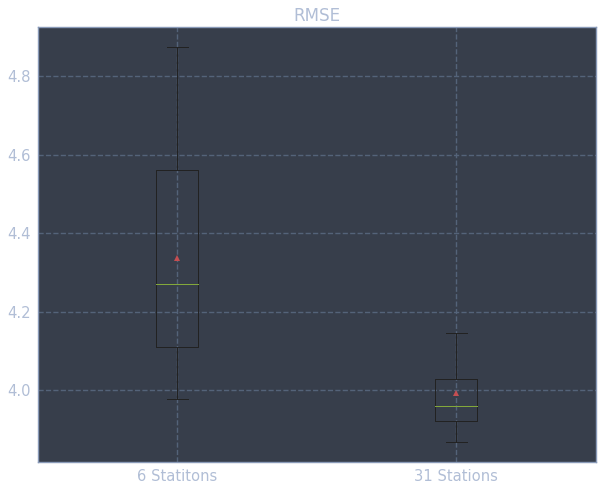

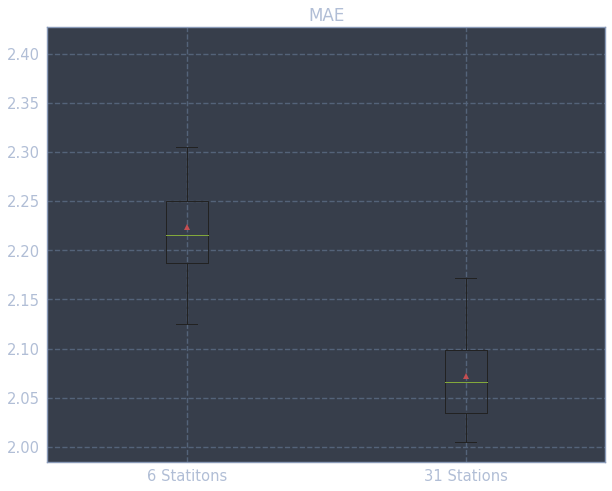

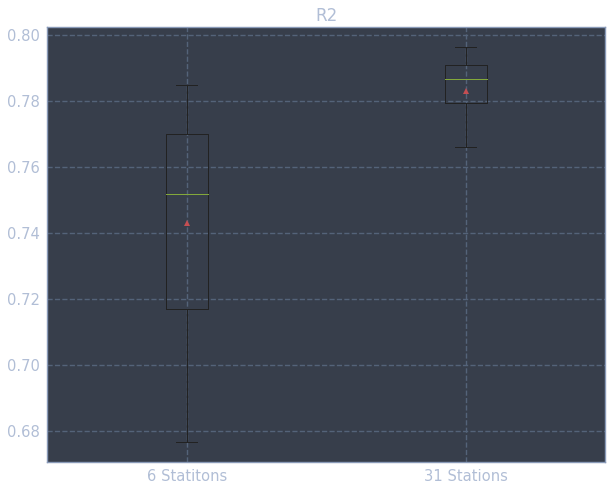

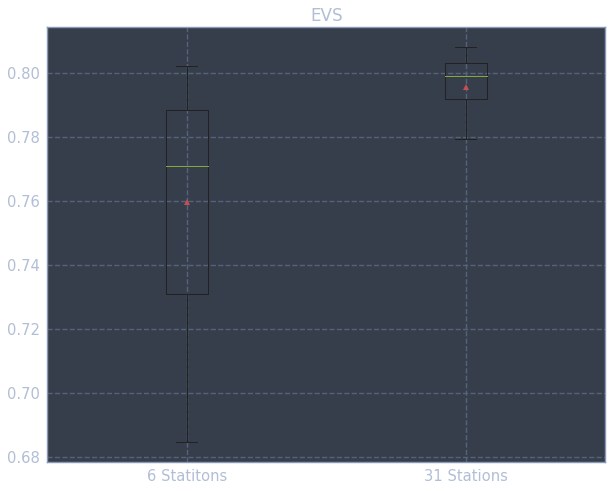

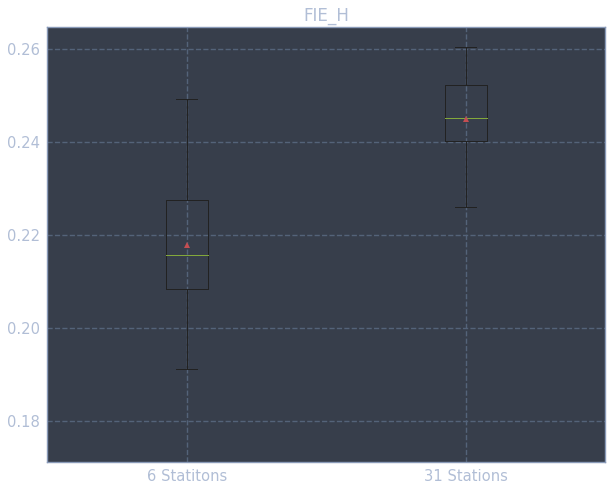

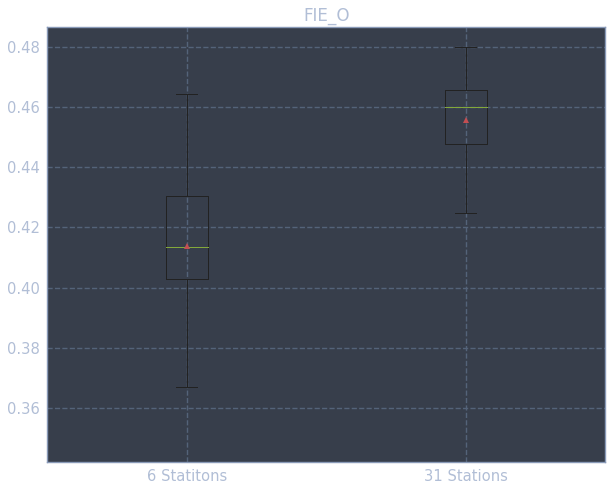

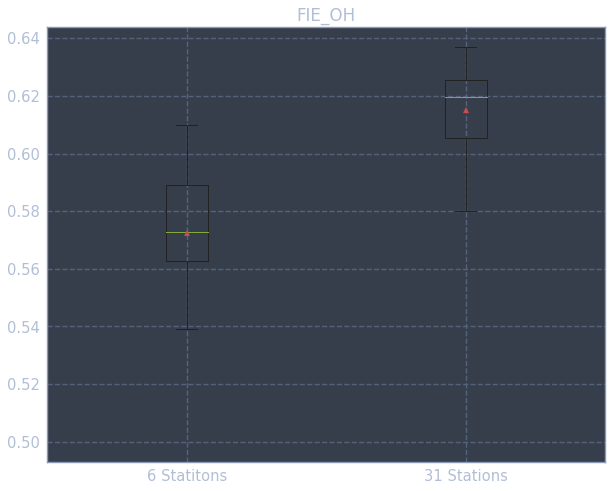

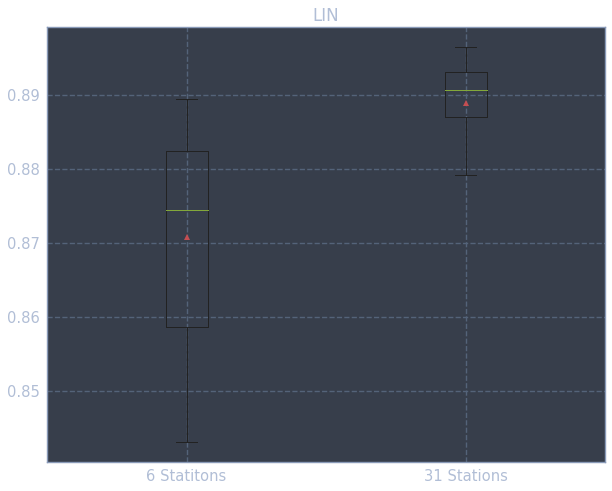

In [15]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1